# Compression using PCA
This notebook shows how to use PCA to compress and decompress an image file. I am using MNIST image displaying digit 3 and 5, that are stored in mnist_image_3.png and mnist_image_5.png, respectively. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from PIL import Image  # Import Pillow for saving/loading

# Load MNIST dataset
# X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

In [9]:
save_path = "mnist_image_3.png" # try different

# # ---- Fix: Normalize to 0-255 (uint8) before saving ----
# img = X[0].reshape(28, 28)  # Reshape to 2D (28x28)

# img_uint8 = (img * 255 / img.max()).astype(np.uint8)  # Scale values properly
# img_pil = Image.fromarray(img_uint8)  # Convert to 8-bit grayscale
# img_pil.save(save_path)
# print(f"Image saved as: {save_path}")

# ---- Load the Image Correctly ----
loaded_img = Image.open(save_path).convert("L")  # Convert to grayscale
loaded_img = np.array(loaded_img)  # Convert to numpy array

# ---- Fix: Normalize back to original scale (0-1) if needed ----
loaded_img = loaded_img / 255.0  # Scale back to 0-1 range

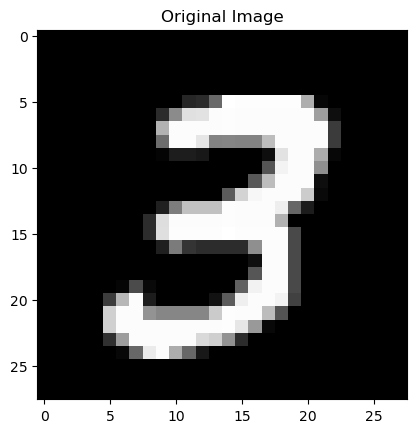

In [10]:
# Select a single image
img = loaded_img  # Reshape to 2D (28x28)

# Show original image
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.show()


In [11]:
# Apply PCA on rows (each row is a feature vector of 28 pixels)
n_components=10
pca = PCA(n_components=n_components)  # Reduce components
compressed_img = pca.fit_transform(img)

Original Shape: (28, 28)
Compressed Shape: (28, 10)
Reconstructed Shape: (28, 28)


explained_var_percent for each component:
[47.72 26.86 11.32  6.38  3.79  1.51  0.97  0.41  0.3   0.27]


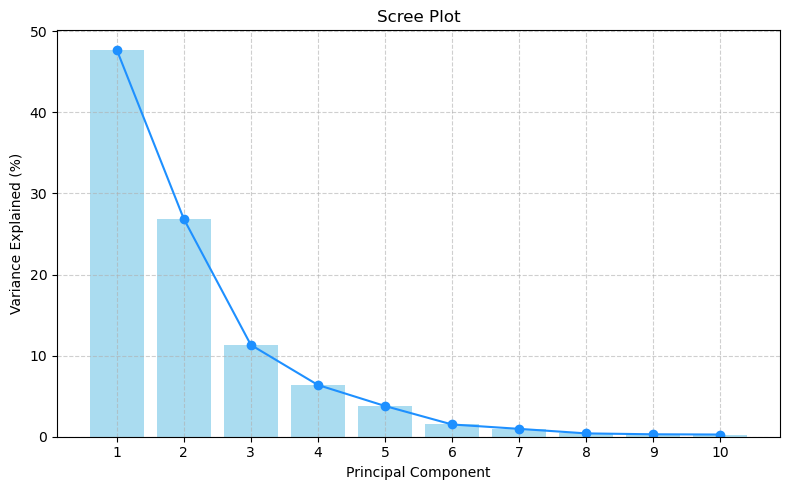

In [22]:
# Get explained variance ratio
explained_var_percent = pca.explained_variance_ratio_ * 100
explained_var_percent = np.round(explained_var_percent,2)
print(f"explained_var_percent for each component:\n{explained_var_percent}")

# Scree plot (no cumulative)
components = np.arange(1, n_components + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, explained_var_percent, marker='o', linestyle='-', color='dodgerblue')
plt.bar(components, explained_var_percent, alpha=0.7, label='Individual', color='skyblue')

plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

explained_var_percent: [48. 27. 11.  6.  4.  2.  1.  0.  0.  0.]
cumulative_var: [48. 75. 86. 92. 96. 98. 99. 99. 99. 99.]


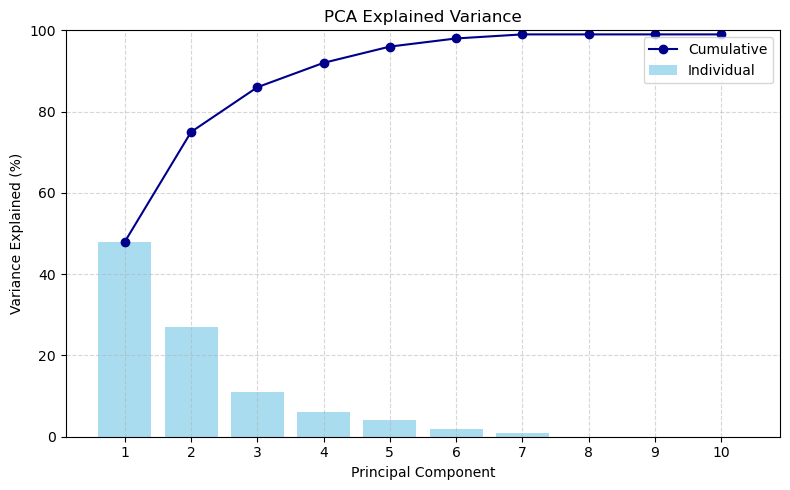

In [24]:
# Explained variance
explained_var = pca.explained_variance_ratio_
explained_var = np.round(explained_var,2)

explained_var_percent = explained_var * 100
explained_var_percent = np.round(explained_var_percent,2)

cumulative_var = np.cumsum(explained_var_percent)
cumulative_var = np.round(cumulative_var,2)

print(f"explained_var_percent: {explained_var_percent}")
print(f"cumulative_var: {cumulative_var}")



# Plot
plt.figure(figsize=(8, 5))
components = np.arange(1, n_components + 1)

# Bar plot for individual explained variance
plt.bar(components, explained_var_percent, alpha=0.7, label='Individual', color='skyblue')

# Line plot for cumulative explained variance
plt.plot(components, cumulative_var, marker='o', color='darkblue', label='Cumulative')

# Plot settings
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA Explained Variance')
plt.xticks(components)
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# observation: 
Using elbow method, it seems that n=5 PC should be good

In [25]:
# Apply PCA on rows (each row is a feature vector of 28 pixels)
n_components=5
pca = PCA(n_components=n_components)  # Reduce components
compressed_img = pca.fit_transform(img)

# Reconstruct the image
reconstructed_img = pca.inverse_transform(compressed_img)

print("Original Shape:", img.shape)
print("Compressed Shape:", compressed_img.shape)
print(f"Reconstructed Shape: {reconstructed_img.shape}")

Original Shape: (28, 28)
Compressed Shape: (28, 5)
Reconstructed Shape: (28, 28)


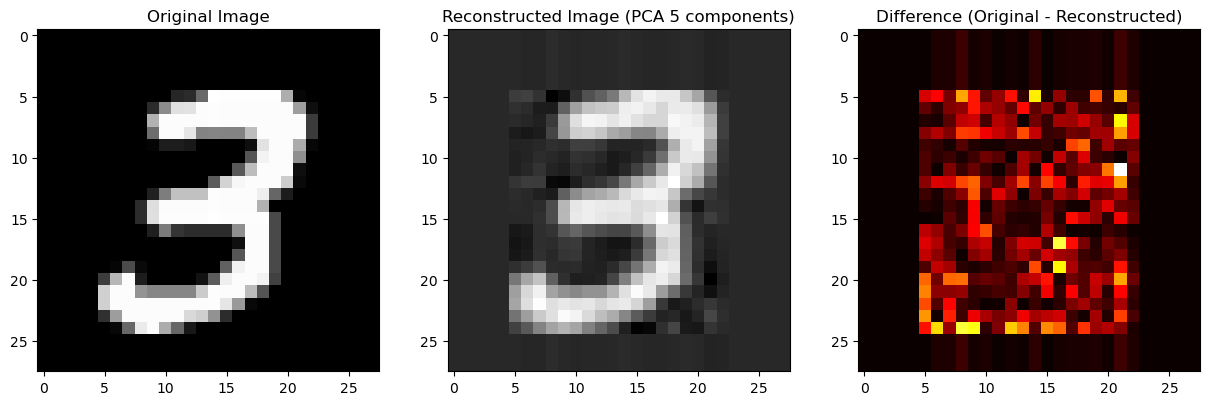

In [26]:
# ---- Show Images ----
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original Image")

# Reconstructed Image
ax[1].imshow(reconstructed_img, cmap='gray')
ax[1].set_title(f"Reconstructed Image (PCA {n_components} components)")

# Difference Image
diff_img = np.abs(img - reconstructed_img)  # Absolute difference
ax[2].imshow(diff_img, cmap='hot')  # 'hot' colormap highlights differences
ax[2].set_title("Difference (Original - Reconstructed)")

plt.show()

Heatmap shows a "Difference" Image (brighter areas = more lost details).

In [27]:
# ---- Size Comparison ----
original_size = img.nbytes
compressed_size = compressed_img.nbytes
reconstructed_size = reconstructed_img.nbytes

print(f"Original Data Size: {original_size:.2f} B")
print(f"Compressed Data Size: {compressed_size:.2f} B")
print(f"Reconstructed Data Size: {reconstructed_size:.2f} B")

Original Data Size: 6272.00 B
Compressed Data Size: 1120.00 B
Reconstructed Data Size: 6272.00 B


**TASK**

1. Try to change n_components to 2, 3, ...10 and see how the quality of image and also size of the compressed image changes

2. Try to change save_path = "mnist_image_3.png", "mnist_image_5.png"

## Key points
Compressed image using PCA can sometimes be larger than the original image.

